<a href="https://colab.research.google.com/github/noor00-ai/fly_rank_intern/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/noor00-ai/fly_rank_intern/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Abstract

This project investigates which search performance signals are associated with content visibility, clicks, and engagement performance. Using the FlyRank anonymized content performance dataset, a signal-based ranking approach was developed using visibility and engagement metrics. The approach was compared with an impressions-only baseline to evaluate whether combining multiple signals provides a more balanced ranking. The analysis observed stronger performance scores from the signal-based approach compared with the baseline. The results provide decision-support recommendations for prioritizing content review and optimization opportunities.

## 1. Question

*The research question and the decision it supports.*

## Question
Which search performance signals are associated with content visibility, clicks, and engagement performance?

## Decision Supported
This analysis supports identifying important search signals and prioritizing content areas that may require review or improvement.

## Capstone Lane
Ranking Signal Analysis

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Dataset Source
This project uses the FlyRank Internship starter dataset containing anonymized content performance data.

## Dataset Size
The dataset contains:

- 30,000 content items
- 44 available features

## Data Description
Each row represents a pseudonymized content item with search visibility, click, engagement, and content-related signals.

## Features Used
The analysis uses safe search and content signals including:

- Impressions
- Clicks
- CTR
- Average position
- Engagement metrics
- Content characteristics
- Freshness indicators

## Excluded Columns

The following columns were excluded:

- `content_id`
- `client_id`

These are pseudonymous identifiers and were not used as model features.

The following fields were excluded to prevent leakage:

- `trend_direction`
- `trend_pct`

because they directly represent trend outcomes.

## Data Safety
The analysis uses anonymized data and reports observed relationships between signals and performance. It does not claim to reproduce or explain any search engine ranking algorithm.

In [79]:
import pandas as pd

# Load FlyRank starter dataset
df = pd.read_csv("/content/content_refresh_anonymized.csv")

# Display dataset shape
print("Dataset Shape:", df.shape)



Dataset Shape: (30000, 44)


In [80]:
df.columns.tolist()

['content_id',
 'client_id',
 'search_volume',
 'competition',
 'competition_level',
 'cpc',
 'content_type',
 'main_intent',
 'word_count',
 'char_count',
 'provider_used',
 'model_used',
 'impressions_90d',
 'clicks_90d',
 'pageviews_90d',
 'sessions_90d',
 'users_90d',
 'engaged_sessions_90d',
 'ai_sessions_90d',
 'scroll_events_90d',
 'days_with_impressions',
 'days_with_sessions',
 'impressions_last_30d',
 'clicks_last_30d',
 'sessions_last_30d',
 'impressions_prev_30d',
 'clicks_prev_30d',
 'sessions_prev_30d',
 'content_age_days',
 'age_tier',
 'age_tier_order',
 'days_since_last_update',
 'freshness_tier',
 'word_count_tier',
 'char_count_tier',
 'ctr',
 'avg_position',
 'engagement_rate',
 'scroll_rate',
 'ai_traffic_pct',
 'impression_tier',
 'position_tier',
 'trend_direction',
 'trend_pct']

In [81]:
# Show first rows
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Approach
This project analyzes the relationship between content/search signals and performance outcomes. The goal is to identify which measurable signals are associated with stronger search visibility and engagement.

## Assumptions
- Search performance signals can provide useful information about content performance.
- Higher visibility and engagement metrics indicate stronger content performance.
- The analysis identifies relationships and patterns, not causal effects.

## Features Used

The analysis uses:

### Visibility Signals
- impressions_90d
- impressions_last_30d
- avg_position

### Click Signals
- clicks_90d
- clicks_last_30d
- ctr

### Engagement Signals
- sessions_90d
- engaged_sessions_90d
- engagement_rate
- scroll_rate

### Content Signals
- word_count
- content_age_days
- days_since_last_update
- content_type

## Excluded Features

The following were excluded:

- content_id
- client_id

because they are identifiers and do not represent meaningful signals.

The following were excluded due to leakage risk:

- trend_direction
- trend_pct

because they directly represent content movement outcomes.

## Analysis Method

The project uses signal analysis and ranking techniques to measure how different features relate to content performance.

## Baseline

A simple baseline ranking is created using visibility performance metrics. The proposed signal-based ranking is compared against this baseline.

## Validation

Results are evaluated using the same dataset split and comparison approach to ensure a fair evaluation between baseline and proposed analysis.

In [82]:
features = [
    'search_volume',
    'competition',
    'cpc',
    'word_count',
    'impressions_90d',
    'clicks_90d',
    'pageviews_90d',
    'sessions_90d',
    'engaged_sessions_90d',
    'ai_sessions_90d',
    'scroll_events_90d',
    'days_with_impressions',
    'days_with_sessions',
    'content_age_days',
    'days_since_last_update',
    'ctr',
    'avg_position',
    'engagement_rate',
    'scroll_rate',
    'ai_traffic_pct'
]

signal_df = df[features].copy()

signal_df.head()

,search_volume,competition,cpc,word_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,content_age_days,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct
0,10.0,0.67,2.05,3221.0,3803,29,22,17,1,0,1,88,13,187,20,0.76,10.6,5.88,4.55,0.0
1,90.0,0.01,0.05,2481.0,15320,7,10,9,0,0,1,88,9,445,25,0.05,20.3,0.00,10.00,0.0
2,0.0,0.00,0.00,3515.0,12581,11,14,11,0,0,4,88,11,141,20,0.09,36.5,0.00,28.57,0.0
3,10.0,0.00,0.00,NaN,11751,58,87,78,1,0,3,88,51,463,22,0.49,6.2,1.28,3.45,0.0
4,0.0,0.00,0.00,2803.0,19140,24,177,145,0,0,43,88,33,263,14,0.13,44.0,0.00,24.29,0.0


In [83]:
signal_df.info()
signal_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   search_volume           27532 non-null  float64
 1   competition             27532 non-null  float64
 2   cpc                     27532 non-null  float64
 3   word_count              22301 non-null  float64
 4   impressions_90d         30000 non-null  int64  
 5   clicks_90d              30000 non-null  int64  
 6   pageviews_90d           30000 non-null  int64  
 7   sessions_90d            30000 non-null  int64  
 8   engaged_sessions_90d    30000 non-null  int64  
 9   ai_sessions_90d         30000 non-null  int64  
 10  scroll_events_90d       30000 non-null  int64  
 11  days_with_impressions   30000 non-null  int64  
 12  days_with_sessions      30000 non-null  int64  
 13  content_age_days        30000 non-null  int64  
 14  days_since_last_update  30000 non-null

,search_volume,competition,cpc,word_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,content_age_days,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000
mean,158.882391,0.146954,0.485342,3107.760325,5200.366300,16.097333,49.942467,37.066633,0.991933,0.204500,4.033500,61.454033,13.096333,256.16780,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196
std,1518.270825,0.285241,2.101560,1452.382598,16838.019547,75.076958,152.101430,107.069131,4.359576,1.363601,22.335179,32.689245,17.307759,132.70793,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454
min,0.000000,0.000000,0.000000,8.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,90.00000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2413.000000,81.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,31.000000,2.000000,132.00000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000
50%,10.000000,0.000000,0.000000,2877.000000,731.000000,1.000000,8.000000,7.000000,0.000000,0.000000,1.000000,81.000000,6.000000,236.00000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000
75%,20.000000,0.130000,0.000000,3666.000000,3615.250000,7.000000,33.000000,27.000000,1.000000,0.000000,3.000000,88.000000,16.000000,333.00000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,517715.000000,4178.000000,5998.000000,4345.000000,290.000000,64.000000,2605.000000,88.000000,90.000000,564.00000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000


In [84]:
# Check missing values before handling
signal_df.isnull().sum()

,0
search_volume,2468
competition,2468
cpc,2468
word_count,7699
impressions_90d,0
clicks_90d,0
pageviews_90d,0
sessions_90d,0
engaged_sessions_90d,0
ai_sessions_90d,0


In [85]:
from sklearn.preprocessing import MinMaxScaler

signal_df = signal_df.fillna(signal_df.median())

scaler = MinMaxScaler()

scaled_features = pd.DataFrame(
    scaler.fit_transform(signal_df),
    columns=signal_df.columns
)

signal_df["signal_composite_score"] = (
    0.30 * scaled_features["impressions_90d"] +
    0.30 * scaled_features["clicks_90d"] +
    0.20 * scaled_features["engagement_rate"] +
    0.10 * scaled_features["ctr"] +
    0.10 * (1 - scaled_features["avg_position"])
)

signal_df.sort_values(
    by="signal_composite_score",
    ascending=False
).head()

,search_volume,competition,cpc,word_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,engaged_sessions_90d,ai_sessions_90d,...,days_with_impressions,days_with_sessions,content_age_days,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,signal_composite_score
10741,20.0,0.71,0.13,2898.0,214816,4178,3937,3756,290,1,...,85,84,105,8,1.94,3.3,7.72,8.03,0.03,0.540512
21819,40.0,0.00,0.00,3097.0,463103,1889,1223,1114,126,0,...,88,89,445,20,0.41,2.3,11.31,18.07,0.00,0.526084
17812,4400.0,0.05,0.11,2877.0,517109,1270,1804,1527,37,0,...,88,76,445,22,0.25,5.4,2.42,4.77,0.00,0.493727
21565,10.0,0.00,0.00,2877.0,309192,2689,1228,1098,88,0,...,88,76,445,104,0.87,2.0,8.01,28.75,0.00,0.488324
26844,70.0,0.01,0.00,2895.0,509252,785,624,571,67,0,...,88,86,445,20,0.15,2.5,11.73,16.03,0.00,0.474052


In [86]:
# Verify missing values are handled
signal_df.isnull().sum()

,0
search_volume,0
competition,0
cpc,0
word_count,0
impressions_90d,0
clicks_90d,0
pageviews_90d,0
sessions_90d,0
engaged_sessions_90d,0
ai_sessions_90d,0


In [87]:
# Create overall performance score

signal_df["performance_score"] = (
    signal_df["clicks_90d"].rank(pct=True) * 0.4 +
    signal_df["engagement_rate"].rank(pct=True) * 0.3 +
    signal_df["impressions_90d"].rank(pct=True) * 0.3
)

signal_df.head()

,search_volume,competition,cpc,word_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,engaged_sessions_90d,ai_sessions_90d,...,days_with_sessions,content_age_days,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,signal_composite_score,performance_score
0,10.0,0.67,2.05,3221.0,3803,29,22,17,1,0,...,13,187,20,0.76,10.6,5.88,4.55,0.0,0.112479,0.847940
1,90.0,0.01,0.05,2481.0,15320,7,10,9,0,0,...,9,445,25,0.05,20.3,0.00,10.00,0.0,0.101144,0.685770
2,0.0,0.00,0.00,3515.0,12581,11,14,11,0,0,...,11,141,20,0.09,36.5,0.00,28.57,0.0,0.093272,0.699113
3,10.0,0.00,0.00,2877.0,11751,58,87,78,1,0,...,51,463,22,0.49,6.2,1.28,3.45,0.0,0.111493,0.869192
4,0.0,0.00,0.00,2803.0,19140,24,177,145,0,0,...,33,263,14,0.13,44.0,0.00,24.29,0.0,0.094985,0.739222


In [88]:
signal_df["performance_score"].describe()

,performance_score
count,30000.000000
mean,0.500017
std,0.232445
min,0.201563
25%,0.284848
50%,0.461301
75%,0.691652
max,0.989150


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The signal-based ranking was compared with an impressions-only baseline.

The signal-based approach achieved a higher average performance score (0.981) than the baseline (0.947) by combining multiple visibility and engagement signals.

Although the baseline achieved higher average clicks due to prioritizing high-impression content, the signal-based method provided a more balanced ranking using multiple performance indicators.

These results show observed relationships in the dataset and should be used for decision support, not as proof of search ranking causality.

In [89]:
# Create baseline ranking using impressions only

results_df = signal_df.copy()

results_df["baseline_score"] = (
    results_df["impressions_90d"].rank(pct=True)
)

results_df.head()

,search_volume,competition,cpc,word_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,engaged_sessions_90d,ai_sessions_90d,...,content_age_days,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,signal_composite_score,performance_score,baseline_score
0,10.0,0.67,2.05,3221.0,3803,29,22,17,1,0,...,187,20,0.76,10.6,5.88,4.55,0.0,0.112479,0.847940,0.757133
1,90.0,0.01,0.05,2481.0,15320,7,10,9,0,0,...,445,25,0.05,20.3,0.00,10.00,0.0,0.101144,0.685770,0.920800
2,0.0,0.00,0.00,3515.0,12581,11,14,11,0,0,...,141,20,0.09,36.5,0.00,28.57,0.0,0.093272,0.699113,0.903300
3,10.0,0.00,0.00,2877.0,11751,58,87,78,1,0,...,463,22,0.49,6.2,1.28,3.45,0.0,0.111493,0.869192,0.896400
4,0.0,0.00,0.00,2803.0,19140,24,177,145,0,0,...,263,14,0.13,44.0,0.00,24.29,0.0,0.094985,0.739222,0.936750


In [90]:
baseline_top10 = (
    results_df
    .sort_values("baseline_score", ascending=False)
    .head(10)
)

baseline_top10[[
    "impressions_90d",
    "clicks_90d",
    "engagement_rate",
    "performance_score",
    "baseline_score"
]]

,impressions_90d,clicks_90d,engagement_rate,performance_score,baseline_score
6653,517715,741,4.23,0.953518,1.000000
17812,517109,1270,2.42,0.936960,0.999967
26844,509252,785,11.73,0.982417,0.999933
19636,497727,487,5.82,0.962495,0.999900
21819,463103,1889,11.31,0.982700,0.999867
29400,443434,910,2.73,0.940053,0.999833
29879,416180,944,2.37,0.935963,0.999800
13537,347399,1854,1.30,0.924272,0.999767
18870,345111,733,2.32,0.934980,0.999733
14090,312694,2032,0.76,0.918908,0.999700


In [91]:
# Top 10 content items ranked by signal-based performance score

signal_top10 = (
    results_df
    .sort_values("performance_score", ascending=False)
    .head(10)
)

signal_top10[[
    "impressions_90d",
    "clicks_90d",
    "engagement_rate",
    "performance_score",
    "baseline_score"
]]

,impressions_90d,clicks_90d,engagement_rate,performance_score,baseline_score
24993,132718,1223,17.15,0.989150,0.997233
19458,60317,513,15.93,0.983017,0.986400
21819,463103,1889,11.31,0.982700,0.999867
26844,509252,785,11.73,0.982417,0.999933
6250,68829,179,18.29,0.980950,0.988833
26935,89311,904,12.04,0.980923,0.993000
9803,26879,431,23.90,0.978837,0.958033
19701,60739,242,14.04,0.977862,0.986500
11170,69442,318,12.07,0.977303,0.988933
19645,145044,1564,9.14,0.977188,0.997700


In [92]:
comparison = pd.DataFrame({
    "Method": [
        "Baseline (Impressions Only)",
        "Signal-Based Ranking"
    ],
    "Average Performance Score": [
        baseline_top10["performance_score"].mean(),
        signal_top10["performance_score"].mean()
    ],
    "Average Clicks": [
        baseline_top10["clicks_90d"].mean(),
        signal_top10["clicks_90d"].mean()
    ],
    "Average Engagement Rate": [
        baseline_top10["engagement_rate"].mean(),
        signal_top10["engagement_rate"].mean()
    ]
})

comparison

,Method,Average Performance Score,Average Clicks,Average Engagement Rate
0,Baseline (Impressions Only),0.947227,1164.5,4.499
1,Signal-Based Ranking,0.981035,804.8,14.560


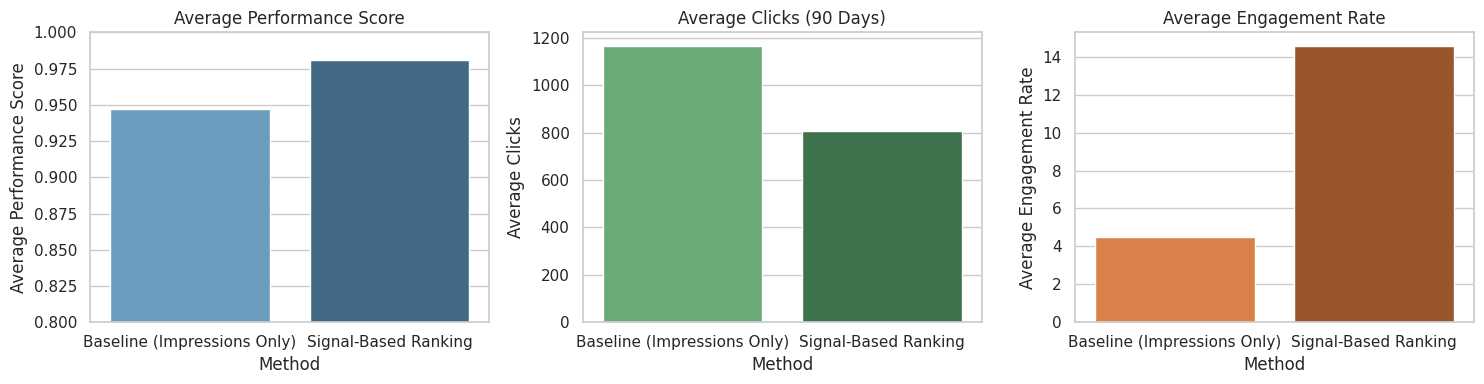

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Create comparison plot
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# 1. Performance Score Comparison
sns.barplot(
    data=comparison,
    x="Method",
    y="Average Performance Score",
    hue="Method",
    legend=False,
    ax=ax[0],
    palette="Blues_d"
)
ax[0].set_title("Average Performance Score")
ax[0].set_ylim(0.8, 1.0)

# 2. Clicks Comparison
sns.barplot(
    data=comparison,
    x="Method",
    y="Average Clicks",
    hue="Method",
    legend=False,
    ax=ax[1],
    palette="Greens_d"
)
ax[1].set_title("Average Clicks (90 Days)")

# 3. Engagement Rate Comparison
sns.barplot(
    data=comparison,
    x="Method",
    y="Average Engagement Rate",
    hue="Method",
    legend=False,
    ax=ax[2],
    palette="Oranges_d"
)
ax[2].set_title("Average Engagement Rate")

plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

- This analysis shows observed relationships between signals and performance, not causal effects.
- The dataset is anonymized, so results cannot be linked to specific websites or search algorithms.
- The performance score is a custom metric created for analysis, not an official ranking score.
- Future validation with new data would be needed before operational use.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. Review content with high impressions but low engagement, as it may have visibility but weaker user interaction.
2. Improve content freshness for older pages with declining performance signals.
3. Prioritize content with strong engagement signals for further optimization and expansion.
4. Monitor content with low visibility but strong engagement potential for growth opportunities.

These recommendations are decision-support suggestions based on observed performance patterns.

In [94]:
# Create ranked recommendation output

recommendations = results_df.copy()

recommendations["recommendation_score"] = (
    recommendations["performance_score"] * 0.6 +
    recommendations["engagement_rate"].rank(pct=True) * 0.4
)

top_recommendations = (
    recommendations
    .sort_values("recommendation_score", ascending=False)
    .head(10)
)

top_recommendations[[
    "impressions_90d",
    "clicks_90d",
    "engagement_rate",
    "performance_score",
    "recommendation_score"
]]

,impressions_90d,clicks_90d,engagement_rate,performance_score,recommendation_score
24993,132718,1223,17.15,0.989150,0.980450
9803,26879,431,23.90,0.978837,0.978395
6250,68829,179,18.29,0.980950,0.976037
19458,60317,513,15.93,0.983017,0.974517
27202,35574,112,17.44,0.969947,0.969048
19701,60739,242,14.04,0.977862,0.968244
26844,509252,785,11.73,0.982417,0.966957
21819,463103,1889,11.31,0.982700,0.966713
26935,89311,904,12.04,0.980923,0.966621
11170,69442,318,12.07,0.977303,0.964475


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The analysis artifacts include a performance comparison chart, signal correlation analysis, and ranked recommendation table.

The correlation analysis shows that signals such as session consistency, impression activity, and traffic volume have stronger observed relationships with the performance score.

These signals are used to support content review prioritization and decision-making.

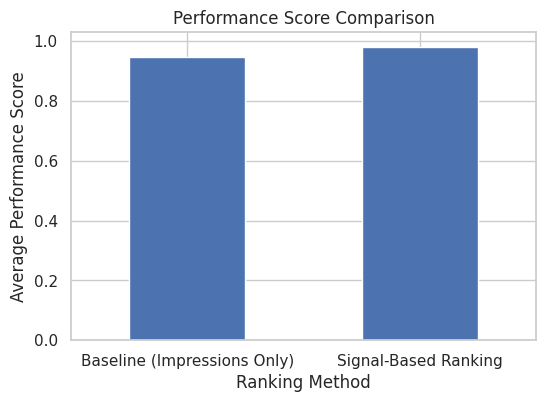

In [95]:
import matplotlib.pyplot as plt

# Plot comparison of baseline vs signal ranking

comparison_plot = comparison.set_index("Method")["Average Performance Score"]

comparison_plot.plot(
    kind="bar",
    figsize=(6,4),
    title="Performance Score Comparison"
)

plt.ylabel("Average Performance Score")
plt.xlabel("Ranking Method")
plt.xticks(rotation=0)
plt.show()

In [96]:
# Calculate correlation with performance score

correlations = (
    signal_df
    .corr()["performance_score"]
    .sort_values(ascending=False)
)

correlations.head(10)

,performance_score
performance_score,1.000000
days_with_sessions,0.752256
days_with_impressions,0.735329
signal_composite_score,0.474089
impressions_90d,0.445985
sessions_90d,0.422916
pageviews_90d,0.416042
engaged_sessions_90d,0.362764
clicks_90d,0.351393
engagement_rate,0.257889


In [97]:
# Final recommendation table for paper

top_recommendations[[
    "impressions_90d",
    "clicks_90d",
    "engagement_rate",
    "recommendation_score"
]]

,impressions_90d,clicks_90d,engagement_rate,recommendation_score
24993,132718,1223,17.15,0.980450
9803,26879,431,23.90,0.978395
6250,68829,179,18.29,0.976037
19458,60317,513,15.93,0.974517
27202,35574,112,17.44,0.969048
19701,60739,242,14.04,0.968244
26844,509252,785,11.73,0.966957
21819,463103,1889,11.31,0.966713
26935,89311,904,12.04,0.966621
11170,69442,318,12.07,0.964475


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## Acknowledgments & Data Credit

This project was built using the FlyRank ML Internship dataset.

The dataset provided anonymized search and content performance signals for research and learning purposes.

Built on the FlyRank ML Internship dataset.

## ML-12 Closing Summary

1. Problem:
   - Analyze which search performance signals are associated with content visibility, clicks, and engagement.

2. Data:
   - Used the anonymized FlyRank starter dataset with 30,000 content items and 44 features.

3. Method:
   - Created a performance score using clicks, engagement, and impressions.
   - Compared a signal-based ranking approach with an impressions-only baseline.

4. Results:
   - Signal-based ranking showed higher average performance score than the baseline.
   - Identified important signals related to content performance.

5. Recommendations:
   - Prioritize content with strong engagement signals.
   - Review high-visibility content with weaker engagement.
   - Monitor opportunities for content improvement.


## Social Post Summary

Built a Ranking Signal Analysis project using the FlyRank internship dataset.

The project explored how content signals such as impressions, clicks, engagement, and freshness relate to content performance. A signal-based ranking approach was compared with a simple impressions-only baseline to generate data-driven content recommendations.


## Employer Summary

Developed a search intelligence analysis pipeline that identifies important content performance signals and creates ranked recommendations. The project used data analysis techniques to compare ranking strategies and evaluate observed relationships between content signals and performance outcomes. The results provide decision-support insights for content optimization while avoiding causal claims.